# Pricing returns protection

What should "add €2 and returns are free" cost, over a €0.50–€8.00 grid?

The retailer's **cost** uses the actual validation outcomes, so it is measured. **Demand and moral hazard are assumptions** — this dataset contains no opt-in or returns-pricing data. Every assumption is in one cell and swept.

**Setup and the price grid.** `np.round(..., 2)` is not cosmetic: raw `np.arange` produces values like 2.0000000000000004, which silently break exact `.loc[]` lookups later.

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit
from src.data import INTERIM, ROOT

FIGURES = ROOT / "figures"
PRICES = np.round(np.arange(0.50, 8.01, 0.10), 2)

## Assumptions

**Every assumption in one cell, by design.** Claim costs are measured from actual outcomes; opt-in elasticity, adverse-selection strength and moral hazard are *assumed*, because no public dataset contains them. Keeping them together makes them easy to challenge and easy to sweep.

In [2]:
RETURN_COST = 8.0        # USD the retailer absorbs per returned order (logistics + handling)
COST_SCENARIOS = [5.0, 8.0, 10.0]
PRICE_SENSITIVITY = 0.45  # logit drop per EUR of price
ADVERSE_SELECTION = 2.0   # logit gain per unit of own return probability above the mean
MORAL_HAZARD = 0.10       # chance an insured non-returner returns anyway
TARGET_TAKE = 0.20        # calibrates the intercept: 20% take rate at EUR 2.00

p = pd.read_parquet(INTERIM / "predictions.parquet")
r = p.pred.values                      # customer's private risk, proxied by the calibrated model
actual = p.any_return.values           # measured outcome, used for realised cost
r_mean = r.mean()
len(p), round(float(r_mean), 4)

(113966, 0.6321)

**Demand curve.** A logistic where price pushes take-up down and a shopper's own return probability pushes it up — that second term is adverse selection made explicit. `brentq` then solves for the intercept that pins average take-up to 20% at $2, anchoring an otherwise arbitrary curve to one plausible real-world number.

In [3]:
def take(price, intercept, r=r):
    return expit(intercept - PRICE_SENSITIVITY * price + ADVERSE_SELECTION * (r - r_mean))

INTERCEPT = brentq(lambda a: take(2.0, a).mean() - TARGET_TAKE, -20, 20)
print(f"intercept {INTERCEPT:.4f}  ->  take rate at EUR2.00 = {take(2.0, INTERCEPT).mean():.3f}")

intercept -0.5837  ->  take rate at EUR2.00 = 0.200


## Profit per offered order

**Cost uses the measured outcome**, inflated by moral hazard: someone who did not return has a 10% chance of returning once returns are free. Profit per offered order is take-up × (price − expected claim).

In [4]:
cost_rate = actual + MORAL_HAZARD * (1 - actual)   # measured outcome, inflated by moral hazard

def profit(price, cost, r=r, cost_rate=cost_rate):
    t = take(price, INTERCEPT, r)
    return float(np.mean(t * (price - cost * cost_rate))), float(t.mean()), float(np.average(r, weights=t))

curve = pd.DataFrame([{"price": pr, "cost": c, **dict(zip(["profit", "take", "optin_risk"], profit(pr, c)))}
                      for c in COST_SCENARIOS for pr in PRICES])
best = curve.loc[curve.groupby("cost").profit.idxmax()].set_index("cost")
best.round(4)

,price,profit,take,optin_risk
cost,,,,
5.0,6.3,0.0849,0.0364,0.7727
8.0,8.0,0.0284,0.0174,0.7749
10.0,8.0,0.0007,0.0174,0.7749


## Adverse selection

**Adverse selection at chosen price points.** For the central cost assumption, this compares the mean risk of opt-ins against the population at $0.50, $2, $4, $6 and $8. The `gap` column is the adverse-selection premium in probability terms: buyers are consistently riskier than average, and the gap grows with price.

In [5]:
sel = curve[curve.cost == RETURN_COST].set_index("price").loc[[0.5, 2.0, 4.0, 6.0, 8.0]]
sel = sel.assign(all_orders_risk=r_mean, gap=lambda d: d.optin_risk - r_mean)
sel[["take", "optin_risk", "all_orders_risk", "gap", "profit"]].round(4)

,take,optin_risk,all_orders_risk,gap,profit
price,,,,,
0.5,0.3213,0.7369,0.6321,0.1048,-1.7963
2.0,0.2000,0.7529,0.6321,0.1208,-0.8413
4.0,0.0948,0.7659,0.6321,0.1338,-0.2181
6.0,0.0414,0.7721,0.6321,0.1401,-0.0143
8.0,0.0174,0.7749,0.6321,0.1428,0.0284


## Flat, risk-based, and gated

**Four pricing policies compared**, including the market-standard $2 and a risk-based price. The gate is `r_eff * RETURN_COST <= 2.00` — only offer coverage where the expected claim actually fits under the price.

In [6]:
flat_price = float(best.loc[RETURN_COST, "price"])
flat_profit = float(best.loc[RETURN_COST, "profit"])
r_eff = r + MORAL_HAZARD * (1 - r)          # risk once insured — what a price must actually cover

def evaluate(price, offer=None):
    t = expit(INTERCEPT - PRICE_SENSITIVITY * price + ADVERSE_SELECTION * (r - r_mean))
    if offer is not None:
        t = t * offer
    return float(np.mean(t * (price - RETURN_COST * cost_rate))), float(t.mean())

eligible_2 = r_eff * RETURN_COST <= 2.00    # who can a EUR2 product actually cover?
risk_price = np.clip(r_eff * RETURN_COST * 1.15, 0.50, 8.00)

rows = [("flat at best price ($%.2f)" % flat_price, *evaluate(flat_price), 1.0),
        ("flat at $2.00, offered to all", *evaluate(2.00), 1.0),
        ("$2.00, gated to coverable orders", *evaluate(2.00, eligible_2), float(eligible_2.mean())),
        ("risk-based, expected cost + 15%", *evaluate(risk_price), 1.0)]
strategies = pd.DataFrame(rows, columns=["strategy", "profit_per_order", "take_rate", "offered_share"])
risk_profit, gate_profit = rows[3][1], rows[2][1]
strategies.round(4)

,strategy,profit_per_order,take_rate,offered_share
0,flat at best price ($8.00),0.0284,0.0174,1.0000
1,"flat at $2.00, offered to all",-0.8413,0.2000,1.0000
2,"$2.00, gated to coverable orders",0.0013,0.0041,0.0543
3,"risk-based, expected cost + 15%",0.0203,0.0406,1.0000


## Sensitivity to return cost

**Sensitivity to the cost of a return**, which turns out to matter more than price: halving the cost of processing a return roughly doubles the tolerable return rate.

In [7]:
def best_for(cost):
    prof = [profit(pr, cost)[0] for pr in PRICES]
    i = int(np.argmax(prof))
    return {"return_cost": cost, "best_price": float(PRICES[i]), "profit_per_order": prof[i]}

sens = pd.DataFrame([best_for(c) for c in [4.0, 5.0, 8.0, 10.0, 15.0, 25.0]])
sens.round(4)

,return_cost,best_price,profit_per_order
0,4.0,5.5,0.1194
1,5.0,6.3,0.0849
2,8.0,8.0,0.0284
3,10.0,8.0,0.0007
4,15.0,8.0,-0.0684
5,25.0,8.0,-0.2066


## Figure

**Profit curves.** Labels sit at the left endpoint where the three curves are well separated; an earlier version put them at the right end where they collided illegibly.

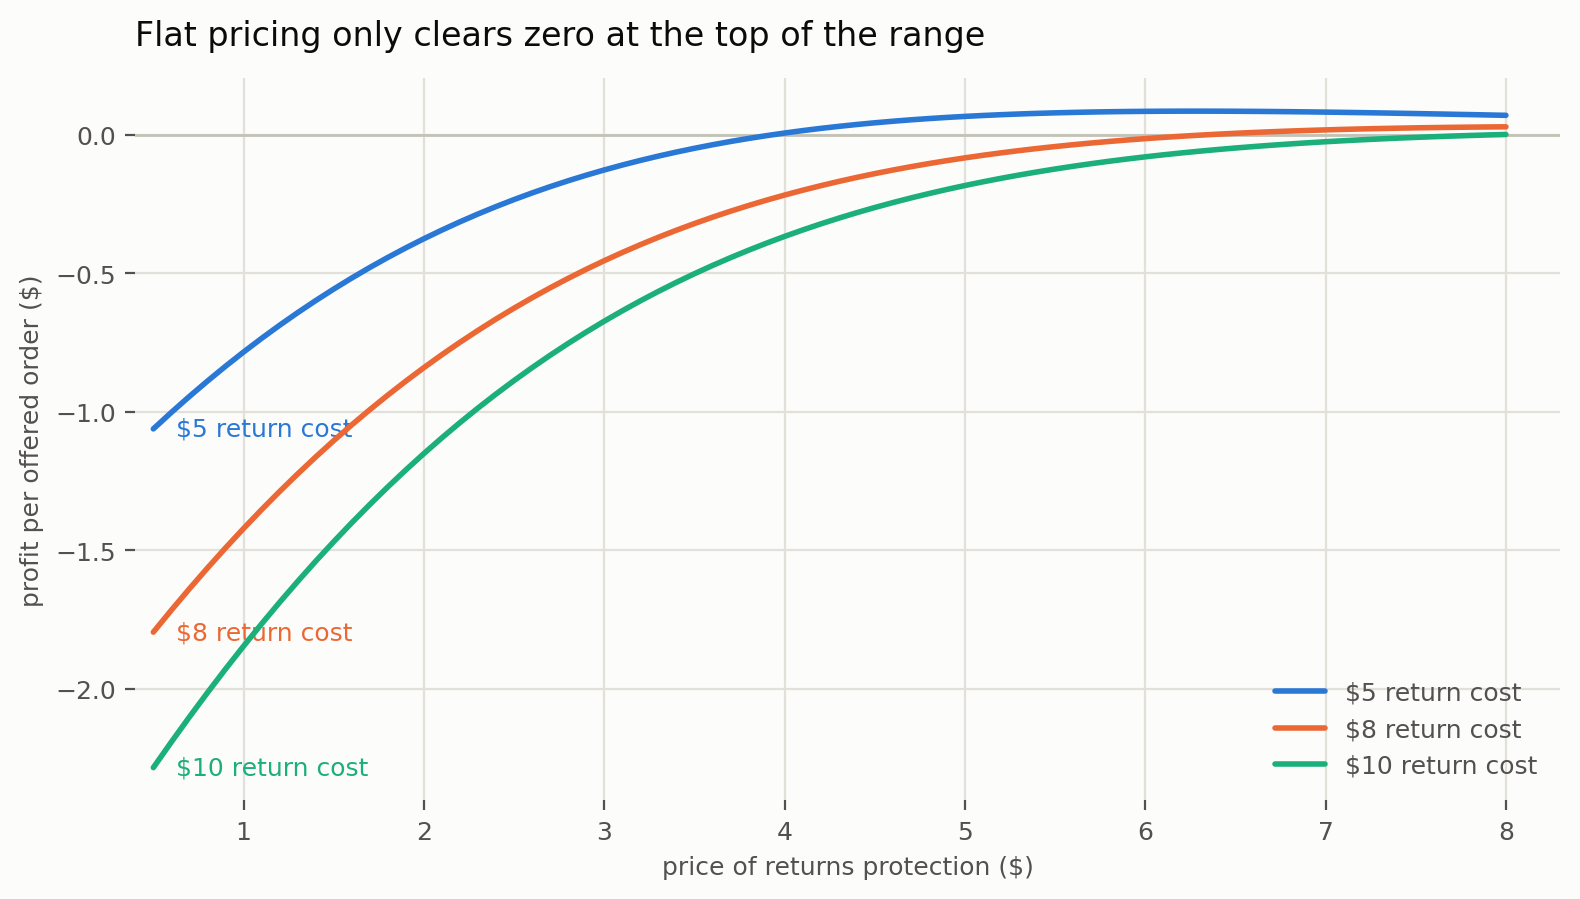

In [8]:
SURFACE, GRID, INK, MUTED, BASE = "#fcfcfb", "#e1e0d9", "#0b0b0b", "#52514e", "#c3c2b7"
SERIES = {5.0: "#2a78d6", 8.0: "#eb6834", 10.0: "#1baf7a"}

fig, ax = plt.subplots(figsize=(8, 4.6), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
for c, colour in SERIES.items():
    d = curve[curve.cost == c]
    ax.plot(d.price, d.profit, color=colour, linewidth=2, solid_capstyle="round",
            zorder=3, label=f"${c:.0f} return cost")
    ax.annotate(f"${c:.0f} return cost", (d.price.iloc[0], d.profit.iloc[0]), xytext=(8, 0),
                textcoords="offset points", color=colour, fontsize=9, va="center", fontweight="medium")
ax.axhline(0, color=BASE, linewidth=1, zorder=2)
ax.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("price of returns protection ($)", color=MUTED, fontsize=9)
ax.set_ylabel("profit per offered order ($)", color=MUTED, fontsize=9)
ax.set_title("Flat pricing only clears zero at the top of the range", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
ax.set_xlim(0.4, 8.3)
leg = ax.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=MUTED)
fig.tight_layout()
FIGURES.mkdir(exist_ok=True)
fig.savefig(FIGURES / "pricing_curve.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Adverse selection curve

**The adverse-selection curve.** Mean risk of those who opt in versus those who decline, at every price. Opt-ins are riskier at every point and the gap *widens* as price rises — raising the price drives away exactly the safe customers you want.

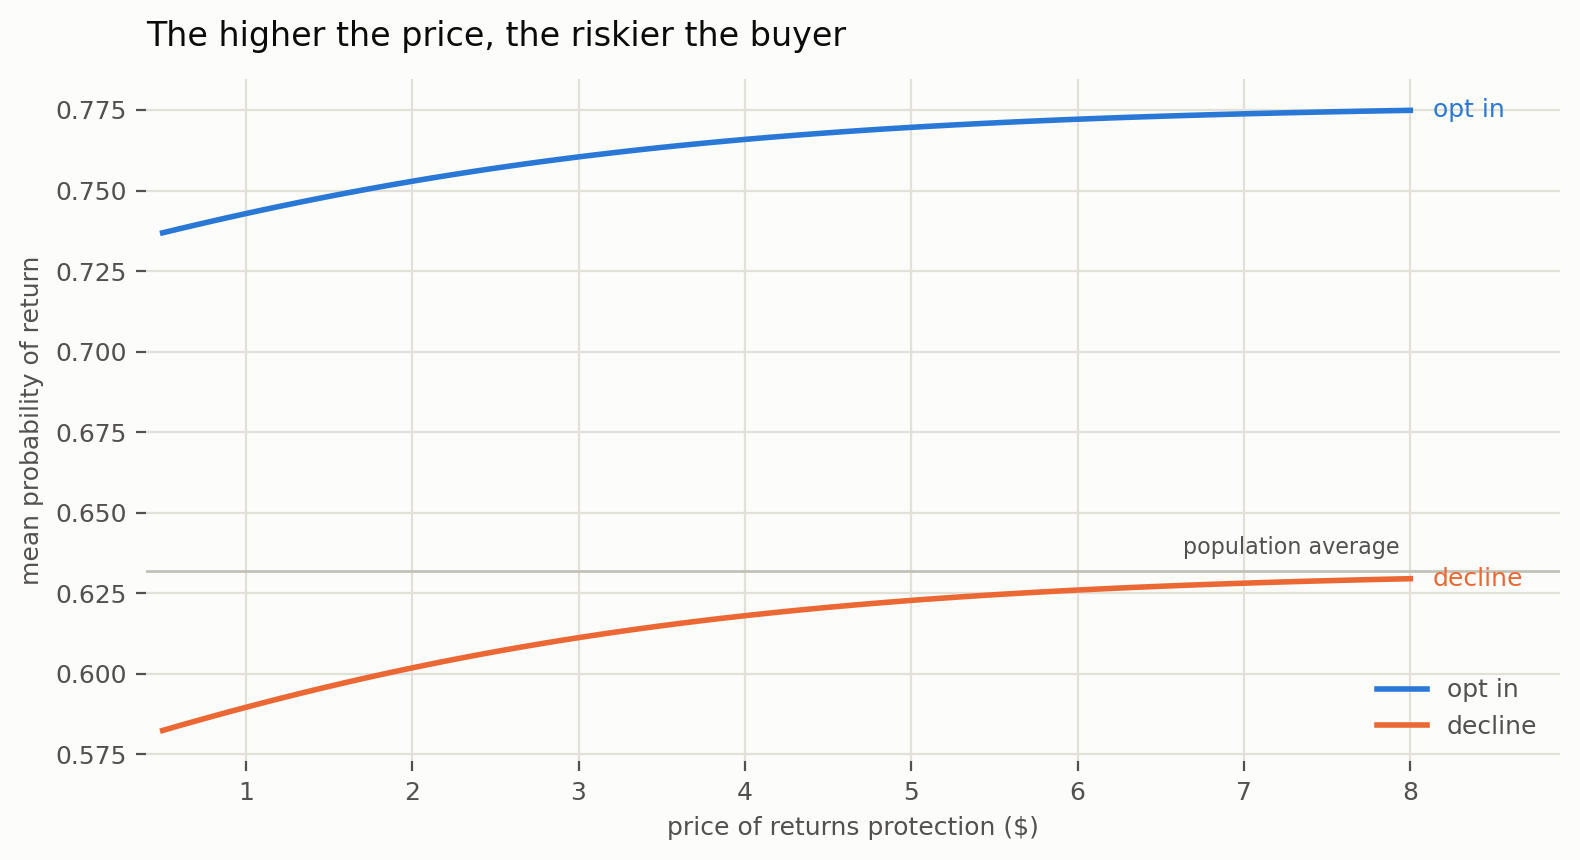

In [9]:
sel_rows = []
for pr in PRICES:
    t = take(pr, INTERCEPT)
    sel_rows.append({"price": pr,
                     "optin_risk": float(np.average(r, weights=t)),
                     "declined_risk": float(np.average(r, weights=1 - t)),
                     "take": float(t.mean())})
sel_curve = pd.DataFrame(sel_rows)

fig, ax = plt.subplots(figsize=(8, 4.4), dpi=200)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.plot(sel_curve.price, sel_curve.optin_risk, color="#2a78d6", linewidth=2, label="opt in", zorder=4)
ax.plot(sel_curve.price, sel_curve.declined_risk, color="#eb6834", linewidth=2, label="decline", zorder=4)
ax.axhline(r_mean, color=BASE, linewidth=1, zorder=2)
ax.annotate("population average", (PRICES[-1], r_mean), xytext=(-4, 6), textcoords="offset points",
            color=MUTED, fontsize=8, ha="right")
for label, col, yv in [("opt in", "#2a78d6", sel_curve.optin_risk.iloc[-1]),
                       ("decline", "#eb6834", sel_curve.declined_risk.iloc[-1])]:
    ax.annotate(label, (PRICES[-1], yv), xytext=(8, 0), textcoords="offset points",
                color=col, fontsize=9, va="center", fontweight="medium")
ax.grid(True, color=GRID, linewidth=0.8, linestyle="-", zorder=1)
ax.set_axisbelow(True)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xlabel("price of returns protection ($)", color=MUTED, fontsize=9)
ax.set_ylabel("mean probability of return", color=MUTED, fontsize=9)
ax.set_title("The higher the price, the riskier the buyer", color=INK, fontsize=12, pad=12, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
ax.set_xlim(0.4, 8.9)
ax.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=MUTED)
fig.tight_layout()
fig.savefig(FIGURES / "adverse_selection.png", facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Save

**Persist the pricing result** along with the assumptions that produced it. Storing the assumption block beside the numbers means a later reader can tell which results depend on measured outcomes and which depend on the modelled demand curve.

In [10]:
summary = {"flat_price": flat_price, "flat_profit": flat_profit, "risk_profit": risk_profit,
           "gate_profit": gate_profit, "return_cost": RETURN_COST,
           "assumptions": {"price_sensitivity": PRICE_SENSITIVITY, "adverse_selection": ADVERSE_SELECTION,
                           "moral_hazard": MORAL_HAZARD, "target_take_at_2": TARGET_TAKE}}
(INTERIM / "pricing.json").write_text(json.dumps(summary, indent=2))
curve.to_csv(INTERIM / "pricing_curve.csv", index=False)
summary

{'flat_price': 8.0,
 'flat_profit': 0.028400575931162735,
 'risk_profit': 0.02026718156219612,
 'gate_profit': 0.0012987475856617973,
 'return_cost': 8.0,
 'assumptions': {'price_sensitivity': 0.45,
  'adverse_selection': 2.0,
  'moral_hazard': 0.1,
  'target_take_at_2': 0.2}}